# HOUM: Hybrid Oversampling and Undersampling Method
## Implementasi HOUM dengan Safe-Level SMOTE (SLS)

In [ ]:
# !pip install smote-variants imbalanced-learn

In [1]:
## Import Library

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

import seaborn as sns

from imblearn.metrics import geometric_mean_score
import smote_variants as sv

warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
## Load Dataset

dataset_path = os.path.join(os.getcwd(), "dataset", "diabetes.csv") # dataset
img_path = os.path.join(os.getcwd(), "img")
os.makedirs(img_path, exist_ok=True)

df = pd.read_csv(dataset_path)

target_col = "Outcome"  # diabetes: Outcome, haberman: survival_status, transfusion: Donated_Blood

X = df.drop(target_col, axis=1).values
y = df[target_col].values

print(f"Dataset: {os.path.basename(dataset_path)}")
print(f"Shape: {X.shape}")
print(f"Features: {list(df.columns[:-1])}")

Dataset: diabetes.csv
Shape: (768, 8)
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [3]:
## Rasio Distribusi Kelas

unique, counts = np.unique(y, return_counts=True)

# Identifikasi kelas mayoritas dan minoritas 
majority_class = unique[np.argmax(counts)]
minority_class = unique[np.argmin(counts)]
n_majority = counts[np.argmax(counts)]
n_minority = counts[np.argmin(counts)]

total = len(y)
ir = n_majority / n_minority

print(f"Total Data      : {total}")
print(f"Kelas Mayoritas : {majority_class} -> {n_majority} ({n_majority/total*100:.2f}%)")
print(f"Kelas Minoritas : {minority_class} -> {n_minority} ({n_minority/total*100:.2f}%)")
print(f"Imbalance Ratio : {ir:.2f}")

Total Data      : 768
Kelas Mayoritas : 0 -> 500 (65.10%)
Kelas Minoritas : 1 -> 268 (34.90%)
Imbalance Ratio : 1.87


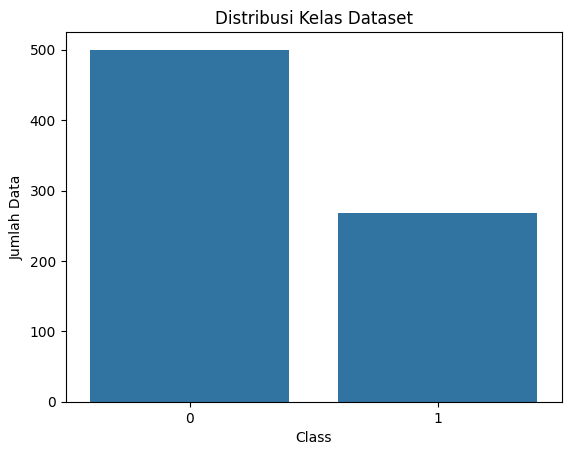

In [4]:
## Visualisasi kelas

# 1. Visualisasi Distribusi Kelas (Bar Chart)
plt.figure()
sns.countplot(x=y)
plt.title("Distribusi Kelas Dataset")
plt.xlabel("Class")
plt.ylabel("Jumlah Data")
plt.savefig(os.path.join(img_path, "distribusi_kelas.png"), dpi=150, bbox_inches='tight')
plt.show()


In [5]:
## Split Dataset (80/20 stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set    : {X_test.shape[0]} samples")
print(f"Train class distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class distribution : {dict(zip(*np.unique(y_test, return_counts=True)))}")

Training set: 614 samples
Test set    : 154 samples
Train class distribution: {np.int64(0): np.int64(400), np.int64(1): np.int64(214)}
Test class distribution : {np.int64(0): np.int64(100), np.int64(1): np.int64(54)}


In [6]:
## HOUM-SLS Algorithm (Eroglu & Pir, 2024)

def is_balanced(y, majority_label, minority_label):
    # pengecekan rasio imbalanced data
    n_maj = np.sum(y == majority_label)
    n_min = np.sum(y == minority_label)
    if n_min == 0:
        return False
    ratio = n_min / n_maj
    return ratio >= 0.9


def houm_sls(X_train, y_train, kernel='rbf', C=1.0, poly_degree=3,
             sls_k=5, majority_label=0, minority_label=1, max_iter=50):

    X_work = X_train.copy()
    y_work = y_train.copy()

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_work)

    iteration = 0

    while not is_balanced(y_work, majority_label, minority_label) and iteration < max_iter:
        iteration += 1

        # UNDERSAMPLING dengan SVM
        svm = SVC(
            kernel=kernel, C=C,
            degree=poly_degree if kernel == 'poly' else 3,
            gamma='scale', random_state=42
        )
        svm.fit(X_scaled, y_work)

        decision_values = svm.decision_function(X_scaled)

        # Q1 dari semua decision values mayoritas, hapus <= Q1
        q1 = np.percentile(decision_values, 25)
        remove_mask = (decision_values <= q1) & (y_work == majority_label)

        X_scaled = X_scaled[~remove_mask]
        y_work = y_work[~remove_mask]

        if is_balanced(y_work, majority_label, minority_label):
            break

        # OVERSAMPLING dengan Safe-Level SMOTE
        n_min_current = np.sum(y_work == minority_label)
        if n_min_current < sls_k + 1:
            break

        try:
            sls = sv.Safe_Level_SMOTE(k_neighbors=sls_k, random_state=42)
            X_scaled, y_work = sls.sample(X_scaled, y_work)
        except Exception as e:
            print(f"  [Warning] Safe-Level SMOTE gagal iterasi {iteration}: {e}")
            break

    n_maj_final = np.sum(y_work == majority_label)
    n_min_final = np.sum(y_work == minority_label)
    print(f"  Selesai setelah {iteration} iterasi | "
          f"Maj: {n_maj_final}, Min: {n_min_final}, "
          f"Rasio: {n_min_final/max(n_maj_final,1):.2f}")

    return X_scaled, y_work, scaler

In [7]:
## Fungsi Evaluasi

def evaluate(y_true, y_pred, y_prob, pos_label=1):
    # rumus 
    auc = roc_auc_score(y_true, y_prob)
    recall = recall_score(y_true, y_pred, pos_label=pos_label)
    precision = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    gmean = geometric_mean_score(y_true, y_pred)

    return {
        "AUC-ROC": round(auc, 4), # evaluasi harus jelas
        "Recall": round(recall, 4),
        "Precision": round(precision, 4),
        "G-Mean": round(gmean, 4)
    }

In [8]:
## Evaluasi Baseline (Imbalanced)

scaler_baseline = MinMaxScaler()
X_train_scaled = scaler_baseline.fit_transform(X_train)
X_test_scaled = scaler_baseline.transform(X_test)

rf_imb = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_imb.fit(X_train_scaled, y_train)

y_pred_imb = rf_imb.predict(X_test_scaled)
y_prob_imb = rf_imb.predict_proba(X_test_scaled)[:, 1]

metrics_imb = evaluate(y_test, y_pred_imb, y_prob_imb, pos_label=minority_class)

print("=" * 50)
print("BASELINE (Imbalanced)")
print("=" * 50)
for k, v in metrics_imb.items():
    print(f"  {k}: {v}")

BASELINE (Imbalanced)
  AUC-ROC: 0.8194
  Recall: 0.6111
  Precision: 0.6471
  G-Mean: 0.7079


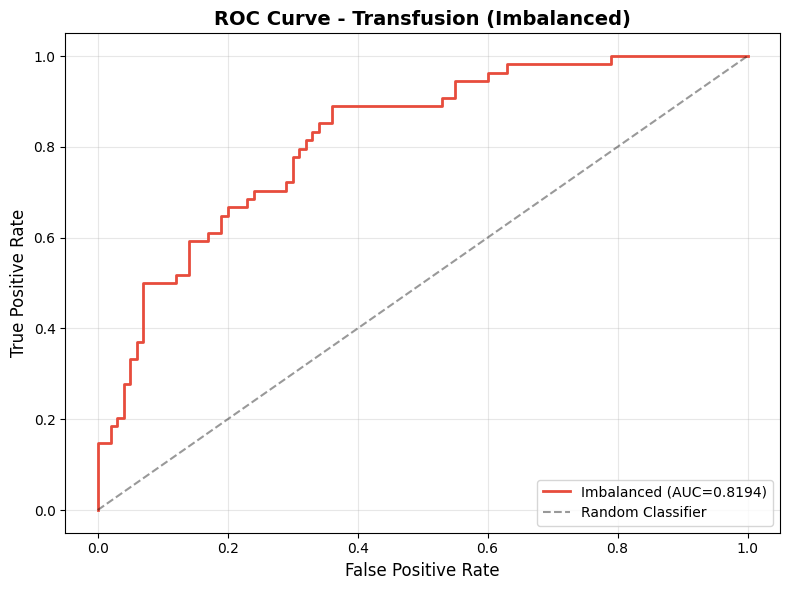

Saved: roc_imbalanced_baseline_transfusin.png


In [9]:
## ROC Curve Baseline (Imbalanced)

fpr_imb, tpr_imb, _ = roc_curve(y_test, y_prob_imb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_imb, tpr_imb, color='#e74c3c', linewidth=2,
         label=f"Imbalanced (AUC={metrics_imb['AUC-ROC']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')

plt.title("ROC Curve - Transfusion (Imbalanced)", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

fname = "roc_imbalanced_baseline_transfusin.png"
plt.savefig(os.path.join(img_path, fname), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fname}")

In [10]:
## Evaluasi Balanced (HOUM-SLS)
## Variasi: 3 Kernel x 6 Nilai C = 18 kombinasi


kernels = ['linear', 'rbf', 'poly']
C_values = [0.5, 1, 1.5, 2, 2.5, 3]

results = []

results.append({
    "Kernel": "-",
    "C": "-",
    "Type": "Imbalanced",
    **metrics_imb
})

roc_data = {k: [] for k in kernels}

for kernel in kernels:
    for C_val in C_values:

        print(f"\n--- HOUM-SLS | Kernel={kernel}, C={C_val} ---")

        X_train_bal, y_train_bal, scaler_bal = houm_sls(
            X_train.copy(), y_train.copy(),
            kernel=kernel, C=C_val,
            majority_label=majority_class,
            minority_label=minority_class
        )

        X_test_bal = scaler_bal.transform(X_test)

        rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
        rf_bal.fit(X_train_bal, y_train_bal)

        y_pred_bal = rf_bal.predict(X_test_bal)
        y_prob_bal = rf_bal.predict_proba(X_test_bal)[:, 1]

        metrics_bal = evaluate(y_test, y_pred_bal, y_prob_bal, pos_label=minority_class)

        print(f"  Metrics: {metrics_bal}")

        results.append({
            "Kernel": kernel,
            "C": C_val,
            "Type": "Balanced (HOUM-SLS)",
            **metrics_bal
        })

        fpr, tpr, _ = roc_curve(y_test, y_prob_bal)
        roc_data[kernel].append({
            'C': C_val,
            'fpr': fpr,
            'tpr': tpr,
            'auc': metrics_bal['AUC-ROC']
        })

2026-05-11 21:29:10,780:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:10,780:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:10,783:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-05-11 21:29:10,921:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:10,922:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:10,923:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski



--- HOUM-SLS | Kernel=linear, C=0.5 ---
  Selesai setelah 1 iterasi | Maj: 254, Min: 254, Rasio: 1.00
  Metrics: {'AUC-ROC': 0.7806, 'Recall': 0.6481, 'Precision': 0.5932, 'G-Mean': np.float64(0.7018)}

--- HOUM-SLS | Kernel=linear, C=1 ---
  Selesai setelah 1 iterasi | Maj: 255, Min: 255, Rasio: 1.00


2026-05-11 21:29:11,056:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:11,059:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:11,059:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-05-11 21:29:11,188:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:11,188:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:11,192:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski


  Metrics: {'AUC-ROC': 0.7863, 'Recall': 0.5926, 'Precision': 0.6154, 'G-Mean': np.float64(0.6885)}

--- HOUM-SLS | Kernel=linear, C=1.5 ---
  Selesai setelah 1 iterasi | Maj: 256, Min: 256, Rasio: 1.00
  Metrics: {'AUC-ROC': 0.7815, 'Recall': 0.6296, 'Precision': 0.6667, 'G-Mean': np.float64(0.7229)}

--- HOUM-SLS | Kernel=linear, C=2 ---
  Selesai setelah 1 iterasi | Maj: 256, Min: 256, Rasio: 1.00


2026-05-11 21:29:11,343:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:11,344:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:11,345:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-05-11 21:29:11,488:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:11,488:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:11,489:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski


...

  Metrics: {'AUC-ROC': 0.7941, 'Recall': 0.6111, 'Precision': 0.6111, 'G-Mean': np.float64(0.6948)}

--- HOUM-SLS | Kernel=poly, C=1.5 ---
  Selesai setelah 1 iterasi | Maj: 252, Min: 252, Rasio: 1.00
  Metrics: {'AUC-ROC': 0.7859, 'Recall': 0.6111, 'Precision': 0.6346, 'G-Mean': np.float64(0.7036)}

--- HOUM-SLS | Kernel=poly, C=2 ---
  Selesai setelah 1 iterasi | Maj: 252, Min: 252, Rasio: 1.00


2026-05-11 21:29:13,174:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")
2026-05-11 21:29:13,175:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:13,178:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
2026-05-11 21:29:13,329:INFO:Safe_Level_SMOTE: Running sampling via ('Safe_Level_SMOTE', "{'proportion': 1.0, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 42, 'class_name': 'Safe_Level_SMOTE'}")


  Metrics: {'AUC-ROC': 0.7961, 'Recall': 0.6296, 'Precision': 0.6296, 'G-Mean': np.float64(0.7097)}

--- HOUM-SLS | Kernel=poly, C=2.5 ---
  Selesai setelah 1 iterasi | Maj: 252, Min: 252, Rasio: 1.00
  Metrics: {'AUC-ROC': 0.8013, 'Recall': 0.6111, 'Precision': 0.6346, 'G-Mean': np.float64(0.7036)}

--- HOUM-SLS | Kernel=poly, C=3 ---


2026-05-11 21:29:13,329:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-05-11 21:29:13,330:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski


  Selesai setelah 1 iterasi | Maj: 252, Min: 252, Rasio: 1.00
  Metrics: {'AUC-ROC': 0.787, 'Recall': 0.6111, 'Precision': 0.6111, 'G-Mean': np.float64(0.6948)}


In [11]:
## Tabel Hasil Evaluasi

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("HASIL EVALUASI HOUM-SLS")
print("=" * 80)
results_df


HASIL EVALUASI HOUM-SLS


,Kernel,C,Type,AUC-ROC,Recall,Precision,G-Mean
0,-,-,Imbalanced,0.8194,0.6111,0.6471,0.7079
1,linear,0.5,Balanced (HOUM-SLS),0.7806,0.6481,0.5932,0.7018
2,linear,1,Balanced (HOUM-SLS),0.7863,0.5926,0.6154,0.6885
3,linear,1.5,Balanced (HOUM-SLS),0.7815,0.6296,0.6667,0.7229
4,linear,2,Balanced (HOUM-SLS),0.7815,0.6296,0.6667,0.7229
5,linear,2.5,Balanced (HOUM-SLS),0.7787,0.6111,0.6226,0.6992
6,linear,3,Balanced (HOUM-SLS),0.7789,0.6481,0.6364,0.7201
7,rbf,0.5,Balanced (HOUM-SLS),0.8191,0.6481,0.6863,0.7379
8,rbf,1,Balanced (HOUM-SLS),0.8146,0.6111,0.6346,0.7036
9,rbf,1.5,Balanced (HOUM-SLS),0.8174,0.6481,0.6604,0.7290


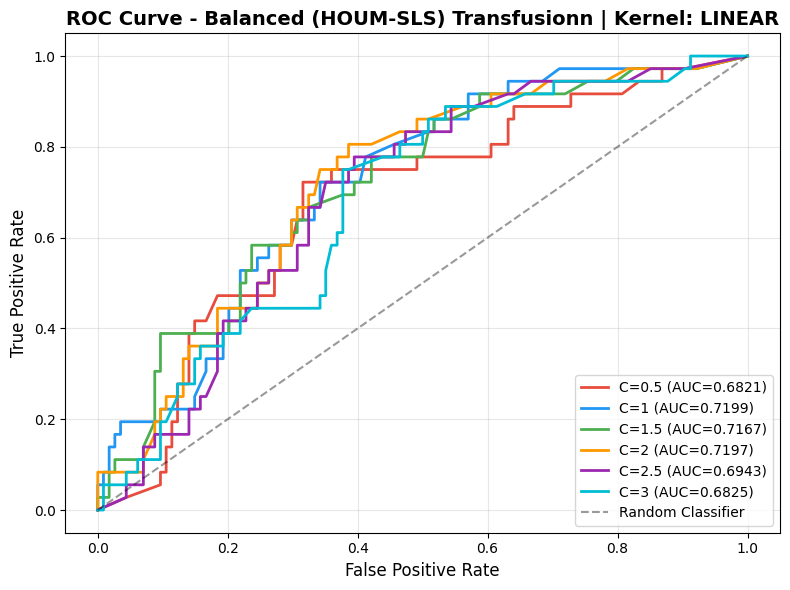

Saved: roc_balanced_transfusion_sls_kernel_linear.png


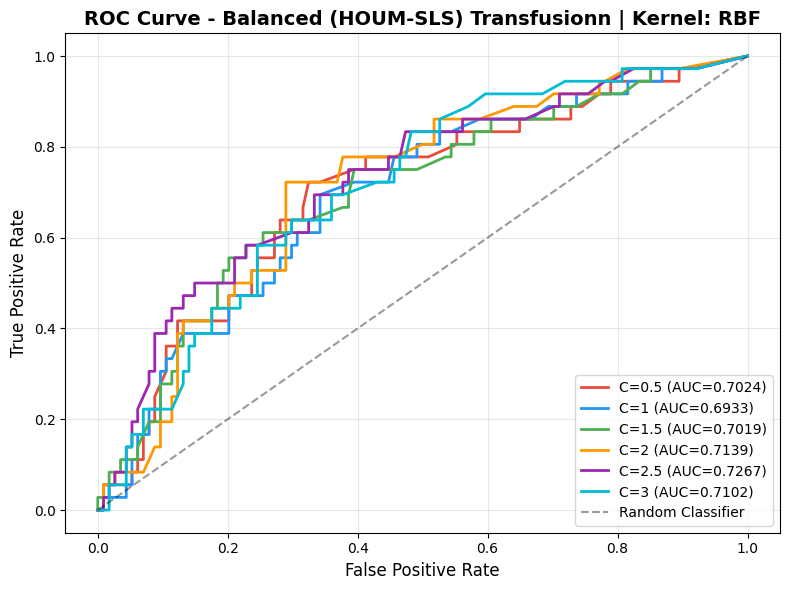

Saved: roc_balanced_transfusion_sls_kernel_rbf.png


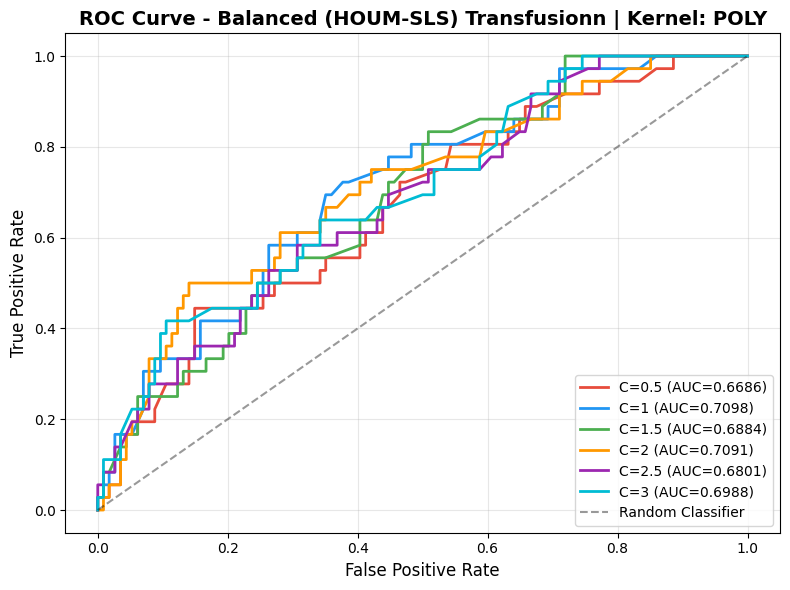

Saved: roc_balanced_transfusion_sls_kernel_poly.png


In [37]:
## Visualisasi ROC Balanced (HOUM-SLS) - Dikelompokkan per Kernel

colors = ['#e74c3c', '#2196f3', '#4caf50', '#ff9800', '#9c27b0', '#00bcd4']

for kernel in kernels:
    plt.figure(figsize=(8, 6))

    for i, rd in enumerate(roc_data[kernel]):
        plt.plot(rd['fpr'], rd['tpr'], color=colors[i], linewidth=2,
                 label=f"C={rd['C']} (AUC={rd['auc']:.4f})")

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Classifier')

    plt.title(f"ROC Curve - Balanced (HOUM-SLS) Transfusionn | Kernel: {kernel.upper()}",
              fontsize=14, fontweight='bold')
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=12)
    plt.legend(fontsize=10, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"roc_balanced_transfusion_sls_kernel_{kernel}.png"
    plt.savefig(os.path.join(img_path, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

In [ ]:
## Export Data Balanced

X_sls_bal, y_sls_bal, scaler_sls = houm_sls(
    X_train.copy(), y_train.copy(),
    majority_label=majority_class,
    minority_label=minority_class
)

print(f"\nJumlah Data HOUM-SLS: {len(y_sls_bal)}")

unique, counts = np.unique(y_sls_bal, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} ({(count/len(y_sls_bal))*100:.2f}%)")

X_sls_bal_original = scaler_sls.inverse_transform(X_sls_bal)

df_sls_bal = pd.DataFrame(X_sls_bal_original, columns=df.columns[:-1])
df_sls_bal[target_col] = y_sls_bal

df_sls_bal.to_csv(os.path.join(os.getcwd(), "balanced_houm_sls.csv"), index=False)
print(f"\nFile balanced_houm_sls.csv berhasil disimpan.")
print(f"Shape dataset: {df_sls_bal.shape}")
df_sls_bal.head()